In [1]:
# import required library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2
from sqlalchemy import create_engine
from scipy.stats import ttest_ind
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

#### 01 Connection with Database


In [2]:
# cerate a connection 
conn = psycopg2.connect(
    host="localhost",
    database="VenderAnalysis",   
    user="postgres",       
    password="Yusufrazakhan12@", 
    port="5432"
)

In [3]:
cur = conn.cursor()

# Table names fetch
cur.execute("""
    SELECT table_name 
    FROM information_schema.tables
    WHERE table_schema = 'public';
""")

tables = cur.fetchall()

# Print table names
print("Tables in database:")
for table in tables:
    print(table[0])

Tables in database:
vendor_sales_summary
begin_inventory
end_inventory
purchases
purchase_prices
sales
vendor_invoice


```Now fetch table from the database which is ("Vendor_sales_summary")```

In [4]:
# fetch table 
data = pd.read_sql('SELECT * FROM "vendor_sales_summary";', conn)
data.head(2)

,vendornumber,vendorname,brand,description,purchaseprice,actualprice,volume,totalpurchasequantity,totalpurchasedollars,totalsalesquantity,totalsalesdollars,totalsalesprice,totalexcisetax,freightcost,grossprofit,profitmargin,stockturnover,salestopurchaseratio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750,145080,3811251.60,142049,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.30,1.0,1.34
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750,164038,3804041.22,160247,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.06,1.0,1.27


#### Exploratory Data Analysis
* Previously, we examined the various tables in the database to identify key variiables, understand their relationships, and determine which ones should be included in the final analysis.

* In this phase of EDA, We will analyze the resultant table to gain insights into the distribution of each column. This will help us understand data patterns, identify anomalies, and ensure data quality before proceeding with further analysis.

In [5]:
# summary statistics
data.describe().T

,count,mean,std,min,25%,50%,75%,max
vendornumber,10692.0,10650.649458,18753.519148,2.00,3951.0000,7153.000,9552.0000,201359.00
brand,10692.0,18039.228769,12662.187074,58.00,5793.5000,18761.500,25514.2500,90631.00
purchaseprice,10692.0,24.385303,109.269375,0.36,6.8400,10.455,19.4825,5681.81
actualprice,10692.0,35.643671,148.246016,0.49,10.9900,15.990,28.9900,7499.99
volume,10692.0,847.360456,664.309309,50.00,750.0000,750.000,750.0000,20000.00
totalpurchasequantity,10692.0,3140.886831,11095.086769,1.00,36.0000,262.000,1975.7500,337660.00
totalpurchasedollars,10692.0,30106.693372,123067.799627,0.71,453.4575,3655.465,20738.2450,3811251.60
totalsalesquantity,10692.0,3077.482136,10952.851391,0.00,33.0000,261.000,1929.2500,334939.00
totalsalesdollars,10692.0,42239.074419,167655.265984,0.00,729.2200,5298.045,28396.9150,5101919.51
totalsalesprice,10692.0,18793.783627,44952.773386,0.00,289.7100,2857.800,16059.5625,672819.31


``` Now we plot the distribution plot to see the value range from where to where it range ```

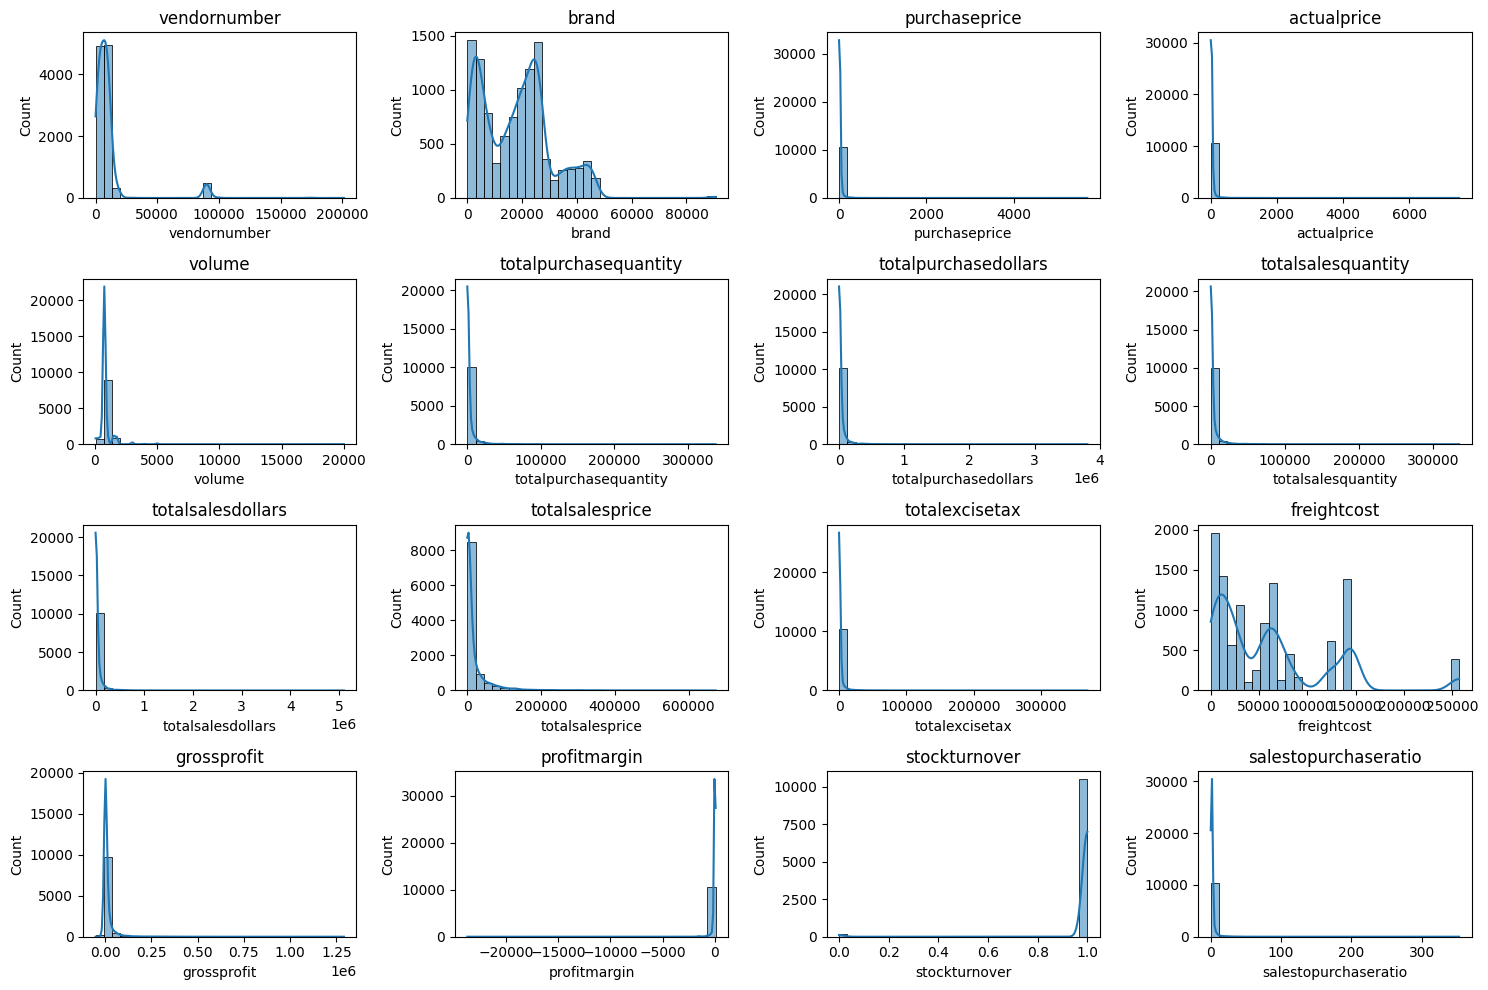

In [6]:
# Distribution plot for Numerical Column 
numerical_cols = data.select_dtypes(include = np.number).columns

plt.figure(figsize = (15,10))
for i , col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1)   # Adjust grid layout as needed
    sns.histplot(data[col], kde = True,bins = 30)
    plt.title(col)
plt.tight_layout()
plt.show()

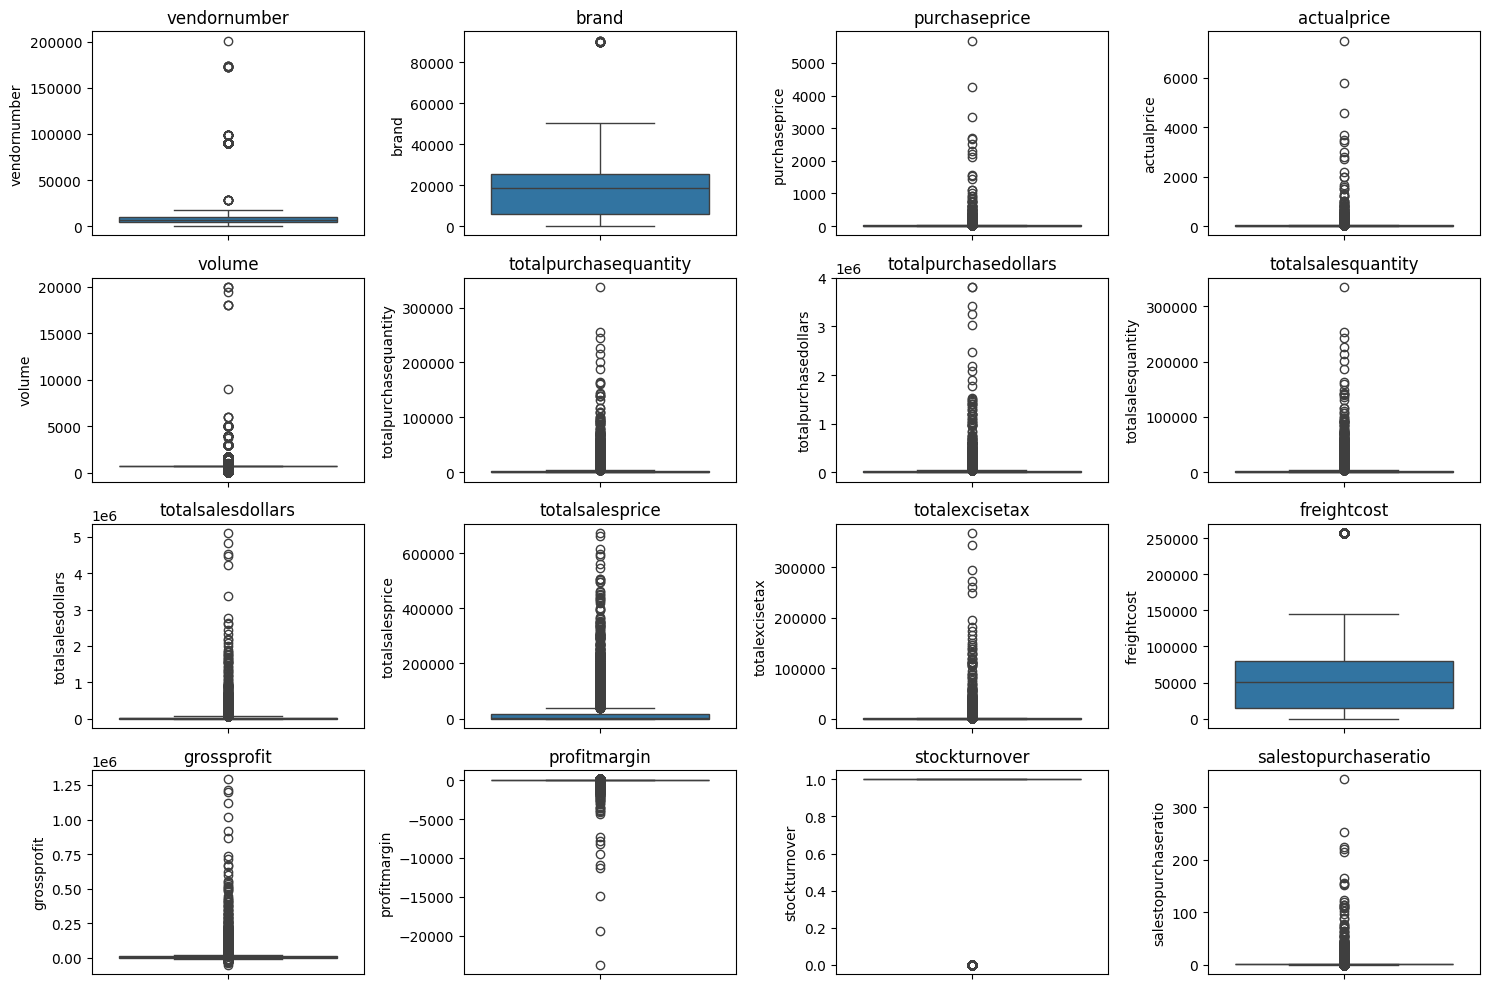

In [7]:
# Now visualize the outliers with the help of Box plot 
plt.figure(figsize = (15,10))
for i , col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1)   # Adjust grid layout as needed
    sns.boxplot(y = data[col])
    plt.title(col)
plt.tight_layout()
plt.show()

#### Summary Statistics Insights:
```Negative & Zero Values:```
* Gross Profit: Minimum value is -52,002.78, indicating losses. Some products or transactions may be selling at a loss due to high costs or selling at discounts lower than the purchase price.

* Profit Margin: Has a minimum of -∞, which suggests cases where revenue is zero or even lower than costs.

* Total Sales Quantity & Sales Dollars: Minimum values are 0, meaning some products were purchased but never sold. These could be slow-moving or obsolete stock.

```Outliers Indicated by High Standard Deviations:```
* Purchase & Actual Prices: The max values (5,681.81 & 7,499.99) are significantly higher than the mean (24.39 & 35.64), indicating potential premium products.

* Freight Cost: Huge variation, from 0.09 to 257,032.07, suggests logistics inefficiencies or bulk shipments.

* Stock Turnover: Ranges from 0 to 274.5, implying some products sell extremely fast while others remain in stock indefinitely. Value more than 1 indicates that sold quantity for that product is higher than purchased quantity due to either sales are being fulfilled from older stock.

In [8]:
# let's filter the data by removing inconsistencies
data = pd.read_sql_query("""select *
from vendor_sales_summary
Where GrossProfit>0
AND ProfitMargin>0
And TotalSalesQuantity>0""",conn)

In [9]:
data

,vendornumber,vendorname,brand,description,purchaseprice,actualprice,volume,totalpurchasequantity,totalpurchasedollars,totalsalesquantity,totalsalesdollars,totalsalesprice,totalexcisetax,freightcost,grossprofit,profitmargin,stockturnover,salestopurchaseratio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750,145080,3811251.60,142049,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.30,1.0,1.34
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750,164038,3804041.22,160247,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.06,1.0,1.27
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750,187407,3418303.68,187140,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.68,1.0,1.33
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750,201682,3261197.94,200412,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.14,1.0,1.37
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750,138109,3023206.01,135838,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.41,1.0,1.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8559,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750,2,2.64,5,15.95,10.96,0.55,27100.41,13.31,83.45,1.0,6.04
8560,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50,6,2.34,134,65.66,1.47,7.04,50293.62,63.32,96.44,1.0,28.06
8561,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50,2,1.48,2,1.98,0.99,0.10,14069.87,0.50,25.25,1.0,1.34
8562,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200,1,1.47,72,143.28,77.61,15.12,257032.07,141.81,98.97,1.0,97.47


``` Now again plot the Distribution Plot after cleaning the data```

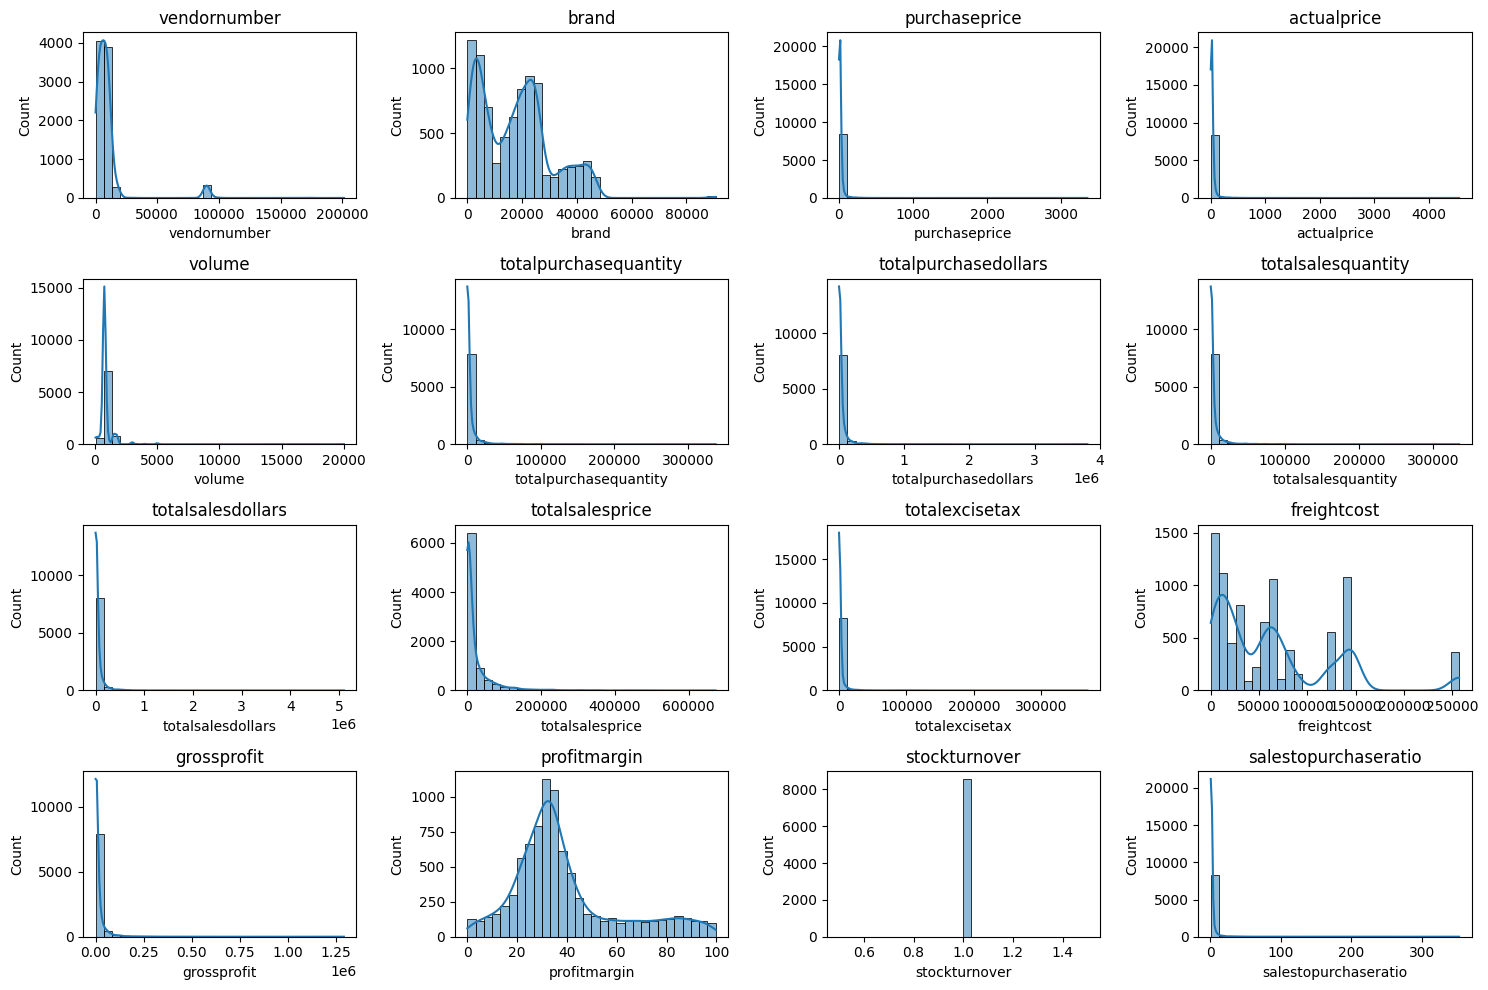

In [10]:
# Distribution plot for Numerical Column 
numerical_cols = data.select_dtypes(include = np.number).columns

plt.figure(figsize = (15,10))
for i , col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1)   # Adjust grid layout as needed
    sns.histplot(data[col], kde = True,bins = 30)
    plt.title(col)
plt.tight_layout()
plt.show()

```  Now see top vendor data and top product data in the dataset```

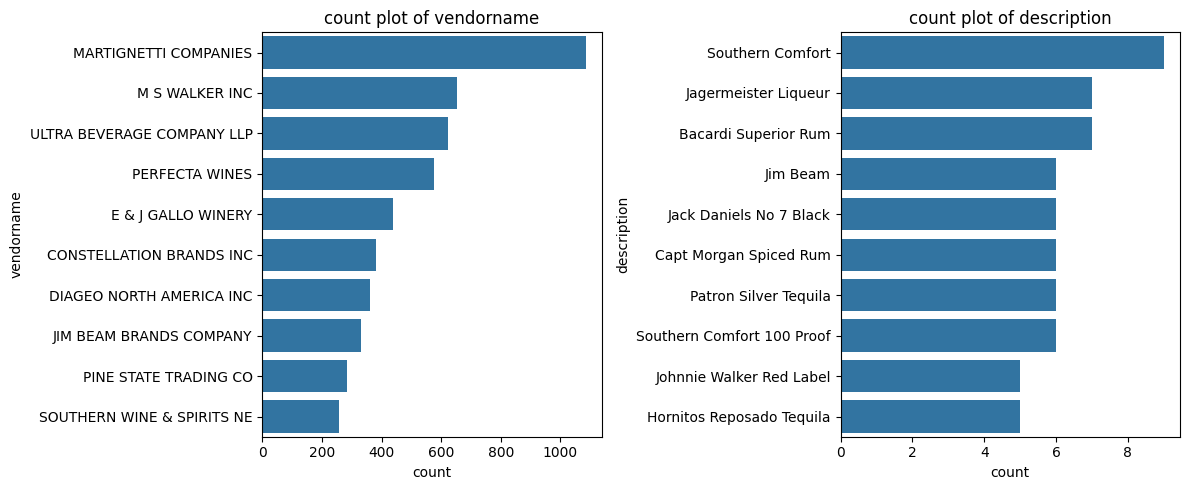

In [11]:
# count plots for categorical columns
categorical_cols = ["vendorname","description"]

plt.figure(figsize = (12,5))
for i , col in enumerate(categorical_cols):
    plt.subplot(1,2,i+1)   # Adjust grid layout as needed
    sns.countplot(y = data[col],order = data[col].value_counts().index[:10])  # Top 10 categories
    plt.title(f"count plot of {col}")
plt.tight_layout()
plt.show()

``` Now see the relationship of all the Numerical variable ``` 

In [12]:
data = data.drop(columns=['stockturnover'], errors='ignore')

In [13]:
data.columns

Index(['vendornumber', 'vendorname', 'brand', 'description', 'purchaseprice',
       'actualprice', 'volume', 'totalpurchasequantity',
       'totalpurchasedollars', 'totalsalesquantity', 'totalsalesdollars',
       'totalsalesprice', 'totalexcisetax', 'freightcost', 'grossprofit',
       'profitmargin', 'salestopurchaseratio'],
      dtype='object')

In [14]:
numerical_cols = [col for col in numerical_cols if col in data.columns]

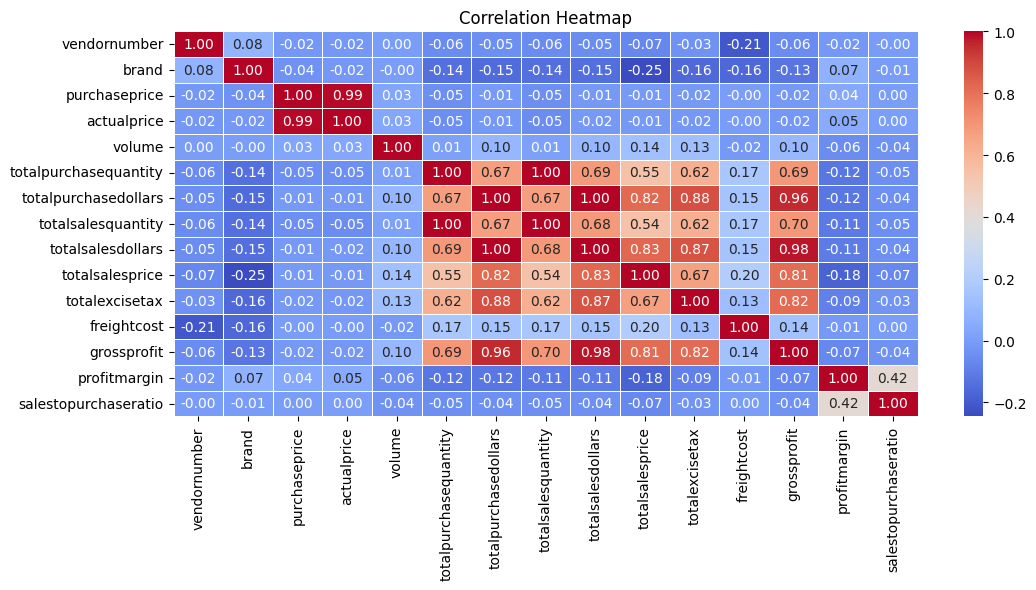

In [15]:
plt.figure(figsize = (12,5))
correlation_matrix = data[numerical_cols].corr()
sns.heatmap(correlation_matrix,annot = True,fmt = ".2f",cmap = "coolwarm",linewidth = 0.5)
plt.title("Correlation Heatmap")
plt.show()

#### Correlation Insights
* PurchasePrice has weak correlations with TotalSalesDollars (-0.012) and GrossProfit (-0.016), suggesting that price variations do not significantly impact sales revenue or profit.

* Strong correlation between total purchase quantity and total sales quantity (0.999), confirming efficient inventory turnover.

* Negative correlation between profit margin & total sales price (-0.179) suggests that as sales price increases, margins decrease, possibly due to competitive pricing pressures.

* StockTurnover has weak negative correlations with both GrossProfit (-0.038) and ProfitMargin (-0.055), indicating that faster turnover does not necessarily result in higher profitability.

### 02 Data Analysis

01 ```Identify brands that needs Promotional and pricing adjustments which exhibit lower sales performance but higher profit margins ?```

In [16]:
data.head()

,vendornumber,vendorname,brand,description,purchaseprice,actualprice,volume,totalpurchasequantity,totalpurchasedollars,totalsalesquantity,totalsalesdollars,totalsalesprice,totalexcisetax,freightcost,grossprofit,profitmargin,salestopurchaseratio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750,145080,3811251.60,142049,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.30,1.34
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750,164038,3804041.22,160247,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.06,1.27
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750,187407,3418303.68,187140,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.68,1.33
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750,201682,3261197.94,200412,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.14,1.37
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750,138109,3023206.01,135838,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.41,1.40


In [17]:
 brand_performance = data.groupby('description').agg({
     'totalsalesdollars':'sum',
     'profitmargin':'mean'}).reset_index()

In [18]:
low_sales_threshold = brand_performance['totalsalesdollars'].quantile(0.15)
high_profit_threshold = brand_performance['profitmargin'].quantile(0.85)

In [19]:
low_sales_threshold

np.float64(560.299)

In [20]:
high_profit_threshold

np.float64(64.96799999999995)

In [21]:
# filter brands with low sales and high profit margin 
target_brands = brand_performance[
    (brand_performance['totalsalesdollars'] <= low_sales_threshold) &
    (brand_performance['profitmargin'] >= high_profit_threshold)
]
print('Brands with Low sales but High Profit Margins:')
display(target_brands.sort_values('totalsalesdollars'))

Brands with Low sales but High Profit Margins:


,description,totalsalesdollars,profitmargin
6199,Santa Rita Organic Svgn Bl,9.99,66.47
2369,Debauchery Pnt Nr,11.58,65.98
2070,Concannon Glen Ellen Wh Zin,15.95,83.45
2188,Crown Royal Apple,27.86,89.81
6237,Sauza Sprklg Wild Berry Marg,27.96,82.15
...,...,...,...
5074,Nanbu Bijin Southern Beauty,535.68,76.75
2271,Dad's Hat Rye Whiskey,538.89,81.85
57,A Bichot Clos Marechaudes,539.94,67.74
6245,Sbragia Home Ranch Merlot,549.75,66.44


``` Now see total sales and their profit margin with the hlp of scatter plot ```

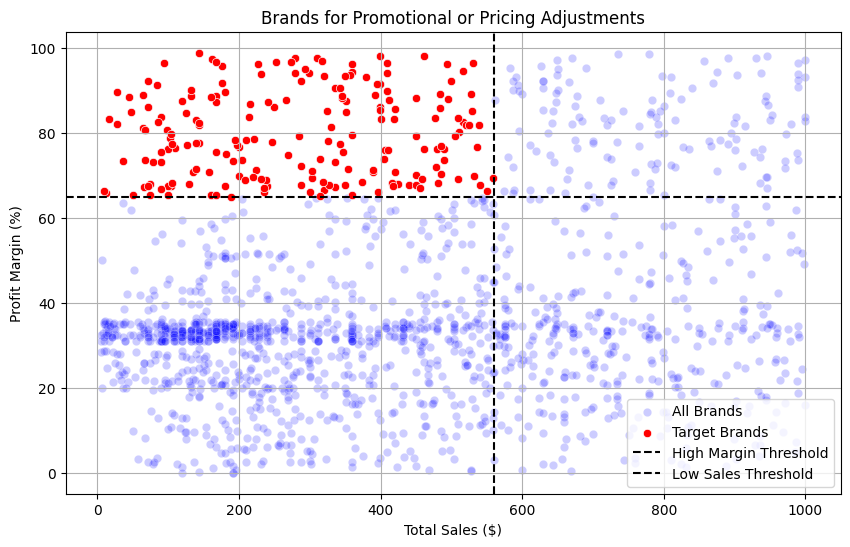

In [22]:
# scatter plot 

brand_performance = brand_performance[brand_performance['totalsalesdollars']<1000]   # for better visualization

plt.figure(figsize=(10, 6))

sns.scatterplot(data=brand_performance, x='totalsalesdollars', y='profitmargin', color="blue", label="All Brands", alpha=0.2)
sns.scatterplot(data=target_brands, x='totalsalesdollars', y='profitmargin', color="red", label="Target Brands")

plt.axhline(high_profit_threshold, linestyle='--', color='black', label="High Margin Threshold")
plt.axvline(low_sales_threshold, linestyle='--', color='black', label="Low Sales Threshold")

plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for Promotional or Pricing Adjustments")
plt.legend()
plt.grid(True)
plt.show()


02 ```Which vendors and brands demonstrate the highest sales performance ```

In [23]:
def format_dollars(value):
    if value >= 1_000_000:
        return f"{value / 1_000_000:.2f}M"
    elif value >= 1_000:
        return f"{value / 1_000:.2f}k"
    else:
        return str(value)

In [24]:
# Top Vendors and Brands by Sales performance.
top_vendors = data.groupby('vendorname')["totalsalesdollars"].sum().nlargest(10)
top_brands = data.groupby('description')["totalsalesdollars"].sum().nlargest(10)
top_vendors

vendorname
DIAGEO NORTH AMERICA INC      67990099.42
MARTIGNETTI COMPANIES         39330359.36
PERNOD RICARD USA             32063196.19
JIM BEAM BRANDS COMPANY       31423020.46
BACARDI USA INC               24854817.14
CONSTELLATION BRANDS INC      24218745.65
E & J GALLO WINERY            18399899.46
BROWN-FORMAN CORP             18247230.65
ULTRA BEVERAGE COMPANY LLP    16502544.31
M S WALKER INC                14706458.51
Name: totalsalesdollars, dtype: float64

In [25]:
top_vendors.apply(lambda x : format_dollars(x))

vendorname
DIAGEO NORTH AMERICA INC      67.99M
MARTIGNETTI COMPANIES         39.33M
PERNOD RICARD USA             32.06M
JIM BEAM BRANDS COMPANY       31.42M
BACARDI USA INC               24.85M
CONSTELLATION BRANDS INC      24.22M
E & J GALLO WINERY            18.40M
BROWN-FORMAN CORP             18.25M
ULTRA BEVERAGE COMPANY LLP    16.50M
M S WALKER INC                14.71M
Name: totalsalesdollars, dtype: object

In [26]:
top_brands.apply(lambda x : format_dollars(x))

description
Jack Daniels No 7 Black    7.96M
Tito's Handmade Vodka      7.40M
Grey Goose Vodka           7.21M
Capt Morgan Spiced Rum     6.36M
Absolut 80 Proof           6.24M
Jameson Irish Whiskey      5.72M
Ketel One Vodka            5.07M
Baileys Irish Cream        4.15M
Kahlua                     3.60M
Tanqueray                  3.46M
Name: totalsalesdollars, dtype: object

``` Now plot these two data using Bar plot ```

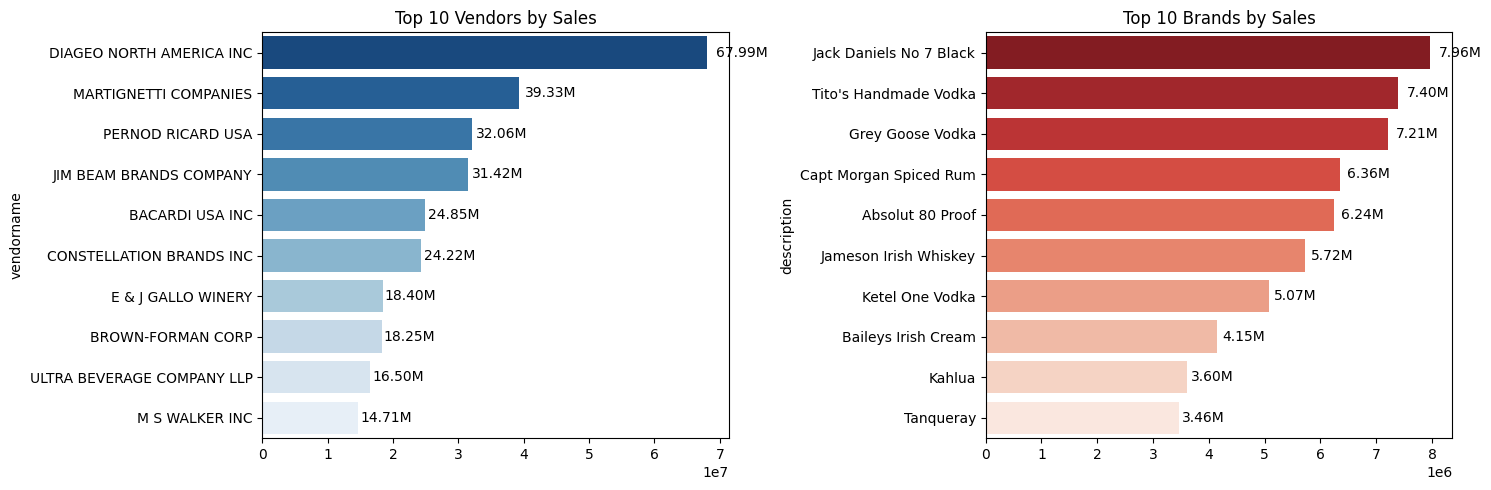

In [27]:
plt.figure(figsize=(15, 5))

# Plot for Top Vendors
plt.subplot(1, 2, 1)
ax1 = sns.barplot(y=top_vendors.index, x=top_vendors.values, palette="Blues_r")
plt.title("Top 10 Vendors by Sales")

for bar in ax1.patches:
    ax1.text(bar.get_width() + (bar.get_width() * 0.02),
             bar.get_y() + bar.get_height() / 2,
             format_dollars(bar.get_width()),
             ha='left', va='center', fontsize=10, color='black')

# Plot for Top Brands
plt.subplot(1, 2, 2)
ax2 = sns.barplot(y=top_brands.index.astype(str), x=top_brands.values, palette="Reds_r")
plt.title("Top 10 Brands by Sales")

for bar in ax2.patches:
    ax2.text(bar.get_width() + (bar.get_width() * 0.02),
             bar.get_y() + bar.get_height() / 2,
             format_dollars(bar.get_width()),
             ha='left', va='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()


03 ```Which vendor contribute the most to total purchase dollars```

In [32]:
vendor_performance = data.groupby('vendorname').agg({
    'totalpurchasedollars':'sum',
    'grossprofit':'sum',
    'totalsalesdollars':'sum'
}).reset_index()

In [33]:
vendor_performance['PurchaseContribution%'] = vendor_performance['totalpurchasedollars'] / data['totalpurchasedollars'].sum()*100

In [34]:
vendor_performance = round(vendor_performance.sort_values("PurchaseContribution%",ascending = False),2)

In [35]:
# Display top 10 vendors..
top_vendors = vendor_performance.head(10)
top_vendors['totalpurchasedollars'] = top_vendors['totalpurchasedollars'].apply(format_dollars)
top_vendors['grossprofit'] = top_vendors['grossprofit'].apply(format_dollars)
top_vendors['totalsalesdollars'] = top_vendors['totalsalesdollars'].apply(format_dollars)
top_vendors

,vendorname,totalpurchasedollars,grossprofit,totalsalesdollars,PurchaseContribution%
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,16.30
57,MARTIGNETTI COMPANIES,25.50M,13.83M,39.33M,8.30
68,PERNOD RICARD USA,23.85M,8.21M,32.06M,7.76
46,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,7.64
6,BACARDI USA INC,17.43M,7.42M,24.85M,5.67
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,4.97
11,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,4.31
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,3.93
106,ULTRA BEVERAGE COMPANY LLP,11.17M,5.34M,16.50M,3.63
53,M S WALKER INC,9.76M,4.94M,14.71M,3.18


In [36]:
top_vendors['cumulative_contribution%'] = top_vendors['PurchaseContribution%'].cumsum()

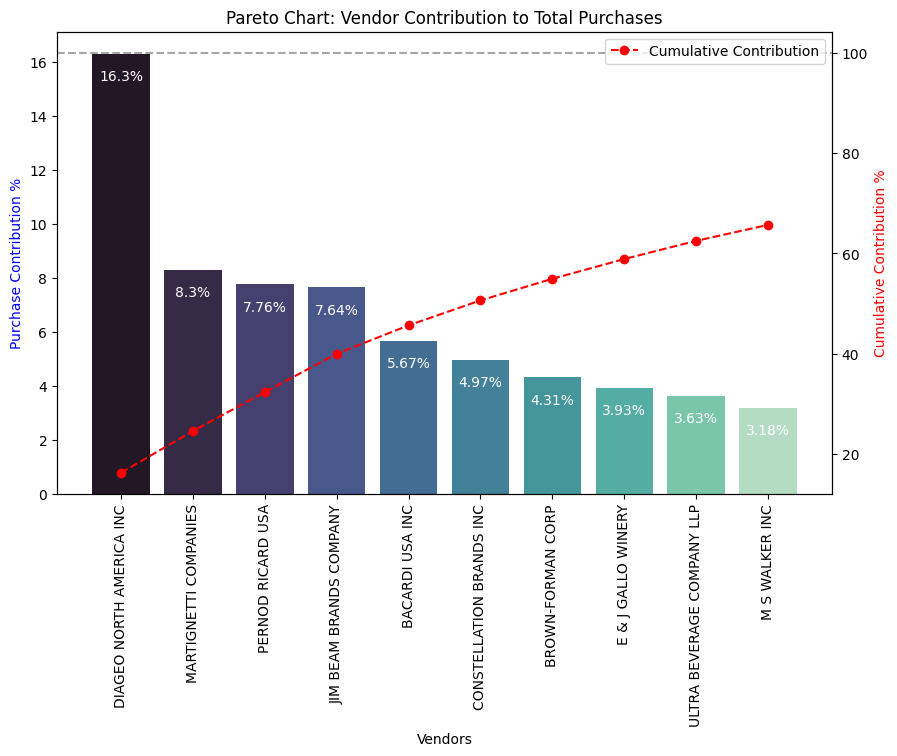

In [37]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar plot for Purchase Contribution%
sns.barplot(x=top_vendors['vendorname'], y=top_vendors['PurchaseContribution%'], palette="mako", ax=ax1)

for i, value in enumerate(top_vendors['PurchaseContribution%']):
    ax1.text(i, value - 1, str(value)+'%', ha='center', fontsize=10, color='white')

# Line Plot for Cumulative Contribution%
ax2 = ax1.twinx()
ax2.plot(top_vendors['vendorname'], top_vendors['cumulative_contribution%'], color='red', marker='o', linestyle='dashed', label='Cumulative Contribution')

ax1.set_xticklabels(top_vendors['vendorname'], rotation=90)
ax1.set_ylabel('Purchase Contribution %', color='blue')
ax2.set_ylabel('Cumulative Contribution %', color='red')
ax1.set_xlabel('Vendors')
ax1.set_title('Pareto Chart: Vendor Contribution to Total Purchases')

ax2.axhline(y=100, color='gray', linestyle='dashed', alpha=0.7)
ax2.legend(loc='upper right')

plt.show()

04 ```How much of total procurement is dependent on the top vendors ?```

In [38]:
print(f"Total Purchases Contribution of top 10 vendors is {round(top_vendors["PurchaseContribution%"].sum(), 2)} %")

Total Purchases Contribution of top 10 vendors is 65.69 %


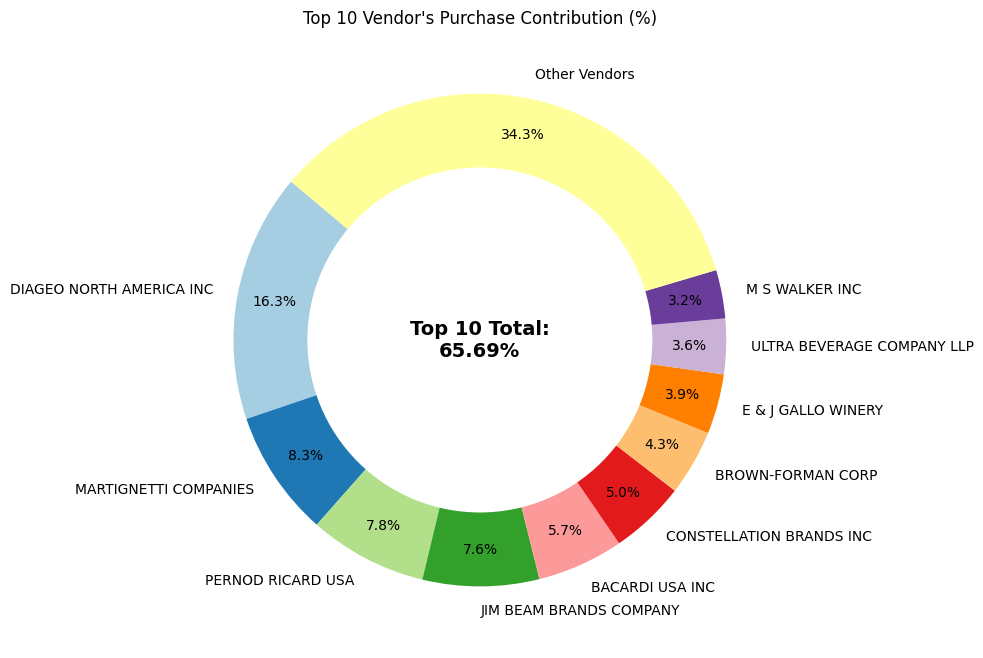

In [39]:
vendors = list(top_vendors['vendorname'].values)
purchase_contributions = list(top_vendors['PurchaseContribution%'].values)
total_contribution = sum(purchase_contributions)
remaining_contribution = 100 - total_contribution

# Append "Other Vendors" category
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)

# Donut Chart
fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    purchase_contributions,
    labels=vendors,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.85,
    colors=plt.cm.Paired.colors
)

# Draw a white circle in the center to create a "donut" effect
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

# Add Total Contribution annotation in the center
plt.text(0, 0, f"Top 10 Total:\n{total_contribution:.2f}%", fontsize=14, fontweight='bold', ha='center', va='center')

plt.title("Top 10 Vendor's Purchase Contribution (%)")
plt.show()


```5. Does Purchasing in bulk reduce the unit price, and what is the optimal purchase volume for cost saving ?```

In [40]:
data['unitpurchaseprice'] = data['totalpurchasedollars']/data['totalpurchasequantity']
data.head()

,vendornumber,vendorname,brand,description,purchaseprice,actualprice,volume,totalpurchasequantity,totalpurchasedollars,totalsalesquantity,totalsalesdollars,totalsalesprice,totalexcisetax,freightcost,grossprofit,profitmargin,salestopurchaseratio,unitpurchaseprice
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750,145080,3811251.60,142049,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.30,1.34,26.27
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750,164038,3804041.22,160247,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.06,1.27,23.19
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750,187407,3418303.68,187140,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.68,1.33,18.24
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750,201682,3261197.94,200412,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.14,1.37,16.17
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750,138109,3023206.01,135838,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.41,1.40,21.89


In [41]:
# now we create another column which is order size 
data['ordersize'] = pd.qcut(data['totalpurchasequantity'],q = 3 , labels = ['small','Medium','Large'])

In [42]:
data[['ordersize','totalpurchasequantity']]

,ordersize,totalpurchasequantity
0,Large,145080
1,Large,164038
2,Large,187407
3,Large,201682
4,Large,138109
...,...,...
8559,small,2
8560,small,6
8561,small,2
8562,small,1


In [43]:
data.groupby('ordersize')[['unitpurchaseprice']].mean()

,unitpurchaseprice
ordersize,
small,39.068186
Medium,15.486414
Large,10.777625


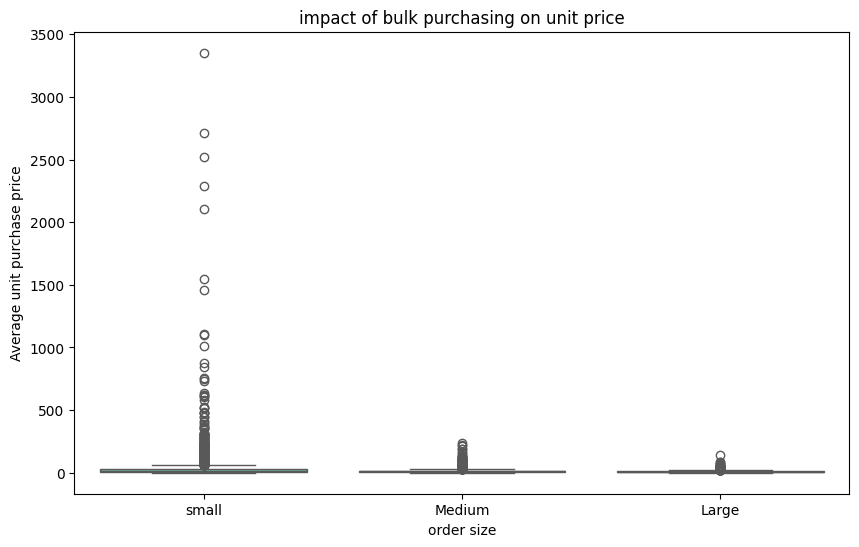

In [44]:
# now plot the box plot 
plt.figure(figsize = (10,6))
sns.boxplot(data = data , x = "ordersize", y = 'unitpurchaseprice', palette = 'Set2')
plt.title('impact of bulk purchasing on unit price')
plt.xlabel('order size')
plt.ylabel('Average unit purchase price')
plt.show()

###
* Vendors buying in bulk (Large Order Size) get the lowest unit price ($10.78 per unit), meaning higher margins if they can manage inventory efficiently.

* The price difference between Small and Large orders is substantial (~72% reduction in unit cost)

* This suggests that bulk pricing strategies successfully encourage vendors to purchase in larger volumes, leading to higher overall sales despite lower per-unit revenue.

```6.  How much capital is locked in unsold inventory per vendor, and which vendors contribute the most it ?```

In [45]:
data['unsoldinventoryvalue'] = (data["totalpurchasequantity"] - data["totalsalesquantity"]) * data['purchaseprice']
print('total unsold capital:', format_dollars(data["unsoldinventoryvalue"].sum()))

total unsold capital: 2.71M


In [46]:
# Aggregate Capital Locked per Vendor
inventory_value_per_vendor = data.groupby("vendorname")["unsoldinventoryvalue"].sum().reset_index()

# Sort Vendors with the Highest Locked Capital
inventory_value_per_vendor = inventory_value_per_vendor.sort_values(by="unsoldinventoryvalue", ascending=False)
inventory_value_per_vendor['unsoldinventoryvalue'] = inventory_value_per_vendor['unsoldinventoryvalue'].apply(format_dollars)
inventory_value_per_vendor.head(10)

,vendorname,unsoldinventoryvalue
25,DIAGEO NORTH AMERICA INC,722.21k
46,JIM BEAM BRANDS COMPANY,554.67k
68,PERNOD RICARD USA,470.63k
116,WILLIAM GRANT & SONS INC,401.96k
30,E & J GALLO WINERY,228.28k
79,SAZERAC CO INC,198.44k
11,BROWN-FORMAN CORP,177.73k
20,CONSTELLATION BRANDS INC,133.62k
61,MOET HENNESSY USA INC,126.48k
77,REMY COINTREAU USA INC,118.60k


```08 What is the 95% confidence intervals for profit margins of top-performing & low-performing vendors ?```

In [47]:
top_threshold = data["totalsalesdollars"].quantile(0.75)
low_threshold = data["totalsalesdollars"].quantile(0.25)

In [48]:
top_vendors =data[data["totalsalesdollars"] >= top_threshold] ["profitmargin"].dropna()
low_vendors = data[data["totalsalesdollars"] <= low_threshold] ["profitmargin"].dropna()

In [49]:
top_vendors

0       25.30
1       21.06
2       24.68
3       27.14
4       28.41
        ...  
3523    79.68
3681    85.78
4751    93.09
4920    95.01
5050    94.27
Name: profitmargin, Length: 2141, dtype: float64

In [50]:
low_vendors

5631     4.11
5652     6.15
5701    12.01
5704     1.68
5724     7.24
        ...  
8559    83.45
8560    96.44
8561    25.25
8562    98.97
8563    99.17
Name: profitmargin, Length: 2141, dtype: float64

In [51]:

def confidence_interval(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data))  # Standard error
    t_critical = stats.t.ppf((1 + confidence) / 2, df=len(data) - 1)
    margin_of_error = t_critical * std_err
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

Top Vendors 95% CI: (30.74, 31.61), Mean: 31.18
Low Vendors 95% CI: (40.50, 42.64), Mean: 41.57


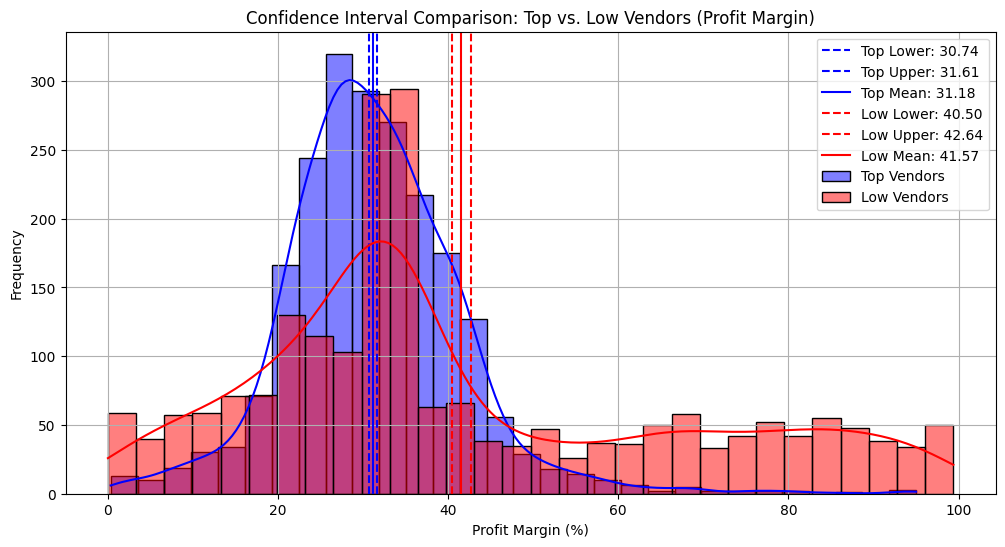

In [52]:
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")

plt.figure(figsize=(12, 6))

# Top Vendors Plot
sns.histplot(top_vendors, kde=True, color="blue", bins=30, alpha=0.5, label="Top Vendors")
plt.axvline(top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower:.2f}")
plt.axvline(top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper:.2f}")
plt.axvline(top_mean, color="blue", linestyle="-", label=f"Top Mean: {top_mean:.2f}")

# Low Vendors Plot
sns.histplot(low_vendors, kde=True, color="red", bins=30, alpha=0.5, label="Low Vendors")
plt.axvline(low_lower, color="red", linestyle="--", label=f"Low Lower: {low_lower:.2f}")
plt.axvline(low_upper, color="red", linestyle="--", label=f"Low Upper: {low_upper:.2f}")
plt.axvline(low_mean, color="red", linestyle="-", label=f"Low Mean: {low_mean:.2f}")

# Finalize Plot
plt.title("Confidence Interval Comparison: Top vs. Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

 * The confidence interval for low-performing vendors (40.48% to 42.62%) is significantly higher than that of top-performing vendors (30.74% to 31.61%).

* This suggests that vendors with lower sales tend to maintain higher profit margins, potentially due to premium pricing or lower operational costs.

* For High-Performing Vendors: if they aim to improve profitability, they could explore selective price adjustments, cost optimization, or bundling strategies.

* For Low-Performing Vendors: Despite higher margins, their low sales volume might indicate a need for better marketing, competitive pricing, or improved distribution strategies.

#### Is ther a significant difference in profit margins between top-performing and low-performing vendors?
Hypothesis:

* H₀(Null Hypothesis): There is no significant difference in the mean profit margins of top-performing and low-performing vendors.

* H₁(Alternative Hypothesis): The mean profit margins of top-performing and low-performing vendors are significant defferent.

In [53]:
top_threshold = data["totalsalesdollars"].quantile(0.75)
low_threshold = data["totalsalesdollars"].quantile(0.25)

top_vendors = data[data["totalsalesdollars"] >= top_threshold] ["profitmargin"].dropna()
low_vendors = data[data["totalsalesdollars"] <= low_threshold] ["profitmargin"].dropna()

# Perform Two-Sample T-Test
t_stat, p_value = ttest_ind(top_vendors, low_vendors, equal_var=False)

# Print results
print(f"T-Statistics: {t_stat:.4f}, P-Value: {p_value:.4f}")
if p_value < 0.05:
    print("Reject H₀: There is a significant differnce in profit margins between top and low-performing vendors.")
else:
    print("Fail to Reject H₀: No significant difference in profit margins.")

T-Statistics: -17.6693, P-Value: 0.0000
Reject H₀: There is a significant differnce in profit margins between top and low-performing vendors.
